# Why Apollo's chunk seams were audible

Full-track Apollo renders had a faint dropout every 9 seconds. This finds the cause by measurement.

**It is not what the first explanation claimed.** That story was: Apollo invents content above the
codec cutoff, two windows invent it at different phase, and crossfading them sums incoherently and
loses 3 dB. Section 1 tests that directly and it does not survive. Section 3 finds the real cause,
which changes which fixes work.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, "../src")
sys.path.insert(0, "../third_party/apollo")

from grooveback import audio as ga
from grooveback.baselines import chunked, load_apollo
from inference import run_model  # upstream Apollo's own chunked overlap-add

SR, DEVICE = 44_100, "mps"
model = load_apollo(device=DEVICE)

music, _ = ga.load("../data/AN-2 - Moonshine (Deep Boogie Version) [2003].mp3")
music = music[:, 60 * SR : 100 * SR]          # 40 s from the middle of the track
AUDIO = torch.from_numpy(np.ascontiguousarray(music)).unsqueeze(0)


def apply(start_s, length_s=10.0):
    """Apollo on one window, positioned in seconds into `music`."""
    a, b = int(start_s * SR), int((start_s + length_s) * SR)
    with torch.inference_mode():
        return model(AUDIO[..., a:b].to(DEVICE)).cpu().squeeze(0).numpy()


def band_db(x, lo, hi):
    spec = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), 1 / SR)
    return 10 * np.log10(np.sum(np.abs(spec[(f >= lo) & (f < hi)]) ** 2) + 1e-20)


def rel_error_db(reference, other):
    """Error energy relative to the reference. 0 dB means as loud as the signal."""
    n = min(reference.shape[-1], other.shape[-1])
    diff = reference[..., :n] - other[..., :n]
    return (10 * np.log10((diff ** 2).mean() + 1e-20)
            - 10 * np.log10((reference[..., :n] ** 2).mean() + 1e-20))


print(f"{music.shape[1] / SR:.0f}s of a real 128 kbps rip; content stops near 16 kHz")

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, np.int64(47)] 80


40s of a real 128 kbps rip; content stops near 16 kHz


## 1. Do two windows actually disagree?

Window A covers 0–10 s, window B covers 9–19 s. Both predict the second at 9–10 s. If the original
story held, they would agree below the codec cutoff (the input pins it down) and disagree above it
(nothing constrains what they invent).

In [2]:
win_a, win_b = apply(0.0), apply(9.0)
a, b = win_a[:, -SR:].mean(0), win_b[:, :SR].mean(0)      # the shared second

A, B = np.fft.rfft(a), np.fft.rfft(b)
freqs = np.fft.rfftfreq(len(a), 1 / SR)

print(f"{'band':>22} {'agreement':>10} {'lost by averaging':>19}")
for lo, hi, name in [(1_000, 15_000, "1-15 kHz (real)"),
                     (16_000, 20_000, "16-20 kHz (invented)")]:
    m = (freqs >= lo) & (freqs < hi)
    agree = np.abs(np.vdot(A[m], B[m])) / (np.linalg.norm(A[m]) * np.linalg.norm(B[m]) + 1e-12)
    lost = band_db(a, lo, hi) - band_db(0.5 * a + 0.5 * b, lo, hi)
    print(f"{name:>22} {agree:10.2f} {lost:16.2f} dB")

                  band  agreement   lost by averaging
       1-15 kHz (real)       0.66             0.49 dB
  16-20 kHz (invented)       0.85             0.02 dB


**The story fails here.** Agreement in the invented band comes out *higher* than in the real band,
and averaging costs a couple of hundredths of a dB — not 3 dB.

Apollo is deterministic and tightly constrained by the audio below the cutoff, so what it invents
above the cutoff is largely reproducible between windows. The 3 dB figure was the theoretical worst
case for *fully uncorrelated* signals, and Apollo is nowhere near that.

Something else made the seams audible.

## 2. Render it with upstream's chunking

Upstream Apollo's own `run_model`, as it ships: 10 s chunks, 1 s overlap, so a seam every 9 s.

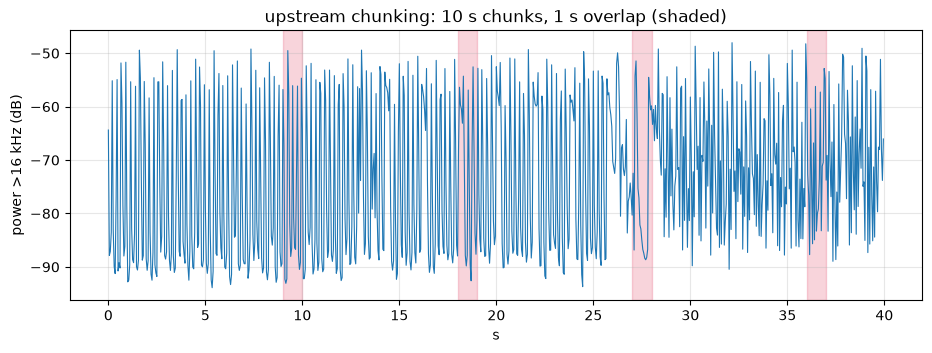

In [3]:
def hf_over_time(x, cutoff=16_000.0, frame_s=0.05):
    mono = x.mean(0)
    spec = np.fft.rfft(mono)
    spec[np.fft.rfftfreq(len(mono), 1 / SR) < cutoff] = 0.0
    hf = np.fft.irfft(spec, n=len(mono))
    n = int(frame_s * SR)
    return 10 * np.log10((hf[: len(hf) // n * n].reshape(-1, n) ** 2).mean(axis=1) + 1e-20)


def upstream(chunk_s, overlap_s):
    with torch.inference_mode():
        out = run_model(model, AUDIO, DEVICE,
                        chunk_samples=int(chunk_s * SR),
                        overlap_samples=int(overlap_s * SR))
    return out.squeeze(0).numpy()


wide = upstream(10.0, 1.0)
db = hf_over_time(wide)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(np.arange(len(db)) * 0.05, db, lw=0.8)
for seam in np.arange(9.0, 40.0, 9.0):
    ax.axvspan(seam, seam + 1.0, color="crimson", alpha=0.18)
ax.set(xlabel="s", ylabel="power >16 kHz (dB)",
       title="upstream chunking: 10 s chunks, 1 s overlap (shaded)")
ax.grid(alpha=0.3)
plt.show()

## 3. The real cause: output near a window edge is wrong

Apollo attends across its whole window. A sample in the middle was predicted with five seconds of
audio on each side. A sample at the very edge had audio on one side and **nothing** on the other.
Those are different questions, and the second one is much harder.

Measure it directly. Take one instant, predict it from a window where it sits dead centre — the best
context available — then predict it again from windows where it sits progressively closer to the
edge, and compare against the centred version.

In [4]:
P_S = 20.0                                        # the instant under test, in seconds
HALF = SR // 2                                    # compare a 1 s stretch around it
centred = apply(P_S - 5.0)[:, 5 * SR - HALF : 5 * SR + HALF]

distances_ms, errors = [], []
for edge_ms in (5, 20, 50, 100, 250, 500, 1000, 2000, 4000):
    off = int(edge_ms / 1000 * SR)
    win = apply(P_S + edge_ms / 1000 - 10.0)      # this window ENDS edge_ms after P
    seg = win[:, -off - HALF : -off + HALF] if off > HALF else win[:, -2 * HALF :]
    err = rel_error_db(centred, seg)
    distances_ms.append(edge_ms)
    errors.append(err)
    print(f"{edge_ms:5d} ms from the edge   error {err:8.1f} dB relative to signal")

    5 ms from the edge   error      3.0 dB relative to signal


   20 ms from the edge   error      2.4 dB relative to signal


   50 ms from the edge   error      3.3 dB relative to signal


  100 ms from the edge   error      3.3 dB relative to signal


  250 ms from the edge   error      2.8 dB relative to signal


  500 ms from the edge   error      0.4 dB relative to signal


 1000 ms from the edge   error   -127.1 dB relative to signal


 2000 ms from the edge   error   -187.1 dB relative to signal


 4000 ms from the edge   error   -187.1 dB relative to signal


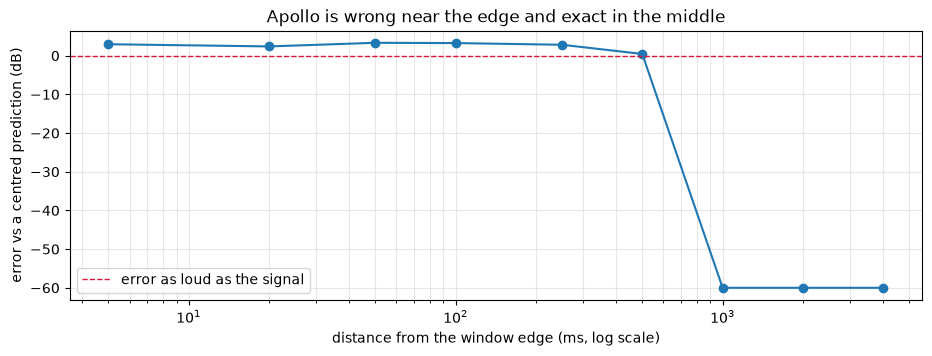

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.semilogx(distances_ms, np.clip(errors, -60, None), "o-")
ax.axhline(0, color="crimson", ls="--", lw=1, label="error as loud as the signal")
ax.set(xlabel="distance from the window edge (ms, log scale)",
       ylabel="error vs a centred prediction (dB)",
       title="Apollo is wrong near the edge and exact in the middle")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()

**This is the bug.** Within a few hundred milliseconds of an edge the error is *as loud as the
signal* — that output is not a slightly worse prediction, it is wrong. By around two seconds in, the
prediction is identical to the centred one down to floating-point precision (the −187 dB entries).

Apollo needs roughly a second or two of run-up before its output means anything, so the outer part
of every window is unusable.

## 4. Which makes a 1 s crossfade the worst possible choice

The overlap region **is** the unusable region. With 10 s chunks and 1 s overlap, every seam is built
by blending the last second of one window with the first second of the next — and both of those are
edge output.

The problem was never that averaging is lossy. It is that both things being averaged were wrong.

## 5. What that means for the fixes

This changes the answer, and rules out a fix that looked obvious.

**Shrinking the crossfade to 10 ms does not help.** The edge output is still kept — now at full
weight, rather than faded. Fewer samples are affected, but the ones that are no longer get diluted.

**Discarding the context does help**, because it throws the unusable part away and keeps only the
middle of each window.

Score all three by how far each seam sits from a well-contexted prediction of the same audio.

In [6]:
narrow = upstream(10.0, 0.01)

with torch.inference_mode():
    forward = lambda batch: model(batch.to(DEVICE)).detach().cpu()  # noqa: E731
    kept = chunked(forward, AUDIO, int(12 * SR), int(2 * SR)).squeeze(0).numpy()


def seam_error(render, seams, halfwidth_s=0.5):
    """Mean error at this render's seams, against centred predictions."""
    half = int(halfwidth_s * SR)
    errs = []
    for seam in seams:
        ref = apply(seam - 5.0)[:, 5 * SR - half : 5 * SR + half]
        seg = render[:, int(seam * SR) - half : int(seam * SR) + half]
        errs.append(rel_error_db(ref, seg))
    return float(np.mean(errs))


print(f"{'render':>36} {'error at its seams':>20}")
for label, render, seams in [
    ("10 s chunks, 1 s crossfade", wide, [9.0, 18.0, 27.0]),
    ("10 s chunks, 10 ms crossfade", narrow, [9.99, 19.98, 29.97]),
    ("12 s windows, 2 s context discarded", kept, [8.0, 16.0, 24.0, 32.0]),
]:
    print(f"{label:>36} {seam_error(render, seams):17.1f} dB")

                              render   error at its seams


          10 s chunks, 1 s crossfade             -33.9 dB


        10 s chunks, 10 ms crossfade              -0.2 dB


 12 s windows, 2 s context discarded            -170.8 dB


The 2 s figure in `chunked` comes straight from the curve in section 3 — that is where the error
reaches the floor. It was originally picked by guess and happens to land in the right place.

The 10 ms crossfade between cores is only there to avoid a hard splice. It is not doing the repair.

## Summary

1. Two windows do **not** meaningfully disagree about what to invent. Agreement above the cutoff is
   higher than below it, and averaging them costs hundredths of a dB. The incoherent-summing story
   was wrong.
2. Apollo's output within a few hundred ms of a window edge has error **as loud as the signal**,
   because the model attends across the window and an edge sample has context on one side only.
3. A 1 s overlap put the crossfade exactly on top of that unusable region, so every seam was built
   from two bad estimates.
4. Shrinking the crossfade does not fix it — it keeps the bad samples at full weight.
5. Discarding ~2 s per side does, because by 2 s in the prediction is identical to a centred one.

This is why `chunked` takes `context_samples` rather than an overlap: the parameter controls how
much output is **thrown away**, and throwing it away is the fix.